# 02. Cell-Type Validation

## Objective

Systematically validate the cell-type annotations derived from unsupervised clustering and marker-gene analysis.

## Main goals

1. Load the processed CID4465 AnnData object.
2. Compare predicted cell types with author-provided annotations.
3. Quantify annotation agreement.
4. Validate canonical marker expression across major cell types.
5. Generate summary figures for downstream tumour microenvironment analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

print("Core libraries loaded successfully.")

Core libraries loaded successfully.


In [2]:
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
processed_dir = data_dir / "processed"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"

print("Project directory:", project_dir)

Project directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME


In [3]:
processed_file = (
    processed_dir / "CID4465_processed.h5ad"
)

print("Processed file exists:", processed_file.exists())

adata = sc.read_h5ad(processed_file)

print(adata)

Processed file exists: True
AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [4]:
print("Observation columns:")
print(adata.obs.columns.tolist())

print("\nPredicted cell types:")
print(
    adata.obs["predicted_celltype"]
    .value_counts()
)

print("\nAuthor-provided major cell types:")
print(
    adata.obs["celltype_major"]
    .value_counts()
)

Observation columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype']

Predicted cell types:
predicted_celltype
CAFs                 374
PVL                  317
Endothelial          287
Myeloid              176
Cancer Epithelial    125
T-cells              116
Plasmablasts          82
B/Plasmablast         57
Name: count, dtype: int64

Author-provided major cell types:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64


In [5]:
annotation_table = pd.crosstab(
    adata.obs["predicted_celltype"],
    adata.obs["celltype_major"]
)

display(annotation_table)

celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
predicted_celltype,,,,,,,,,
B/Plasmablast,21,0,0,0,1,0,0,35,0
CAFs,0,366,0,0,0,0,8,0,0
Cancer Epithelial,3,0,113,0,0,9,0,0,0
Endothelial,0,1,0,284,1,0,0,0,1
Myeloid,0,0,0,0,176,0,0,0,0
PVL,0,9,0,1,0,0,306,0,1
Plasmablasts,8,0,0,0,0,0,0,74,0
T-cells,1,0,0,0,0,0,0,1,114


In [6]:
pred_to_author = {
    "Endothelial": ["Endothelial"],
    "PVL": ["PVL"],
    "CAFs": ["CAFs"],
    "Cancer Epithelial": [
        "Cancer Epithelial",
        "Normal Epithelial"
    ],
    "T-cells": ["T-cells"],
    "Myeloid": ["Myeloid"],
    "Plasmablasts": ["Plasmablasts"],
    "B/Plasmablast": [
        "B-cells",
        "Plasmablasts"
    ]
}

In [7]:
correct = 0

for predicted, allowed_author_types in pred_to_author.items():
    subset = adata.obs[
        adata.obs["predicted_celltype"] == predicted
    ]

    correct += subset[
        subset["celltype_major"].isin(
            allowed_author_types
        )
    ].shape[0]

agreement = correct / adata.n_obs

print("Annotation agreement:")
print(f"{agreement * 100:.2f}%")

Annotation agreement:
97.65%


In [8]:
# Row-normalized annotation agreement table

annotation_prop = pd.crosstab(
    adata.obs["predicted_celltype"],
    adata.obs["celltype_major"],
    normalize="index"
)

display(annotation_prop.round(3))

celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
predicted_celltype,,,,,,,,,
B/Plasmablast,0.368,0.000,0.000,0.000,0.018,0.000,0.000,0.614,0.000
CAFs,0.000,0.979,0.000,0.000,0.000,0.000,0.021,0.000,0.000
Cancer Epithelial,0.024,0.000,0.904,0.000,0.000,0.072,0.000,0.000,0.000
Endothelial,0.000,0.003,0.000,0.990,0.003,0.000,0.000,0.000,0.003
Myeloid,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
PVL,0.000,0.028,0.000,0.003,0.000,0.000,0.965,0.000,0.003
Plasmablasts,0.098,0.000,0.000,0.000,0.000,0.000,0.000,0.902,0.000
T-cells,0.009,0.000,0.000,0.000,0.000,0.000,0.000,0.009,0.983


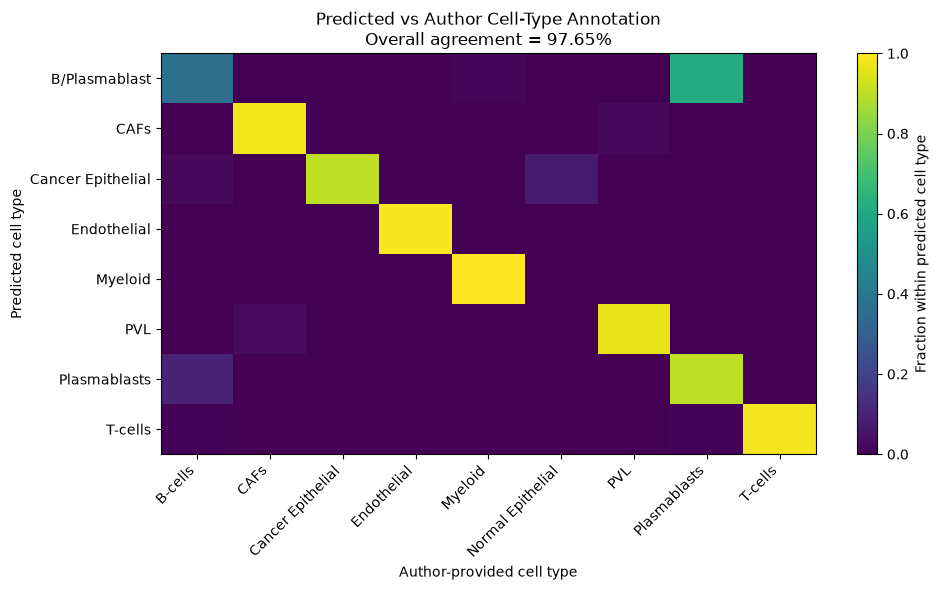

In [9]:
# Annotation agreement heatmap

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    annotation_prop.values,
    aspect="auto"
)

ax.set_xticks(range(len(annotation_prop.columns)))
ax.set_xticklabels(
    annotation_prop.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(annotation_prop.index)))
ax.set_yticklabels(annotation_prop.index)

ax.set_xlabel("Author-provided cell type")
ax.set_ylabel("Predicted cell type")
ax.set_title(
    f"Predicted vs Author Cell-Type Annotation\n"
    f"Overall agreement = {agreement * 100:.2f}%"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Fraction within predicted cell type")

plt.tight_layout()
plt.show()

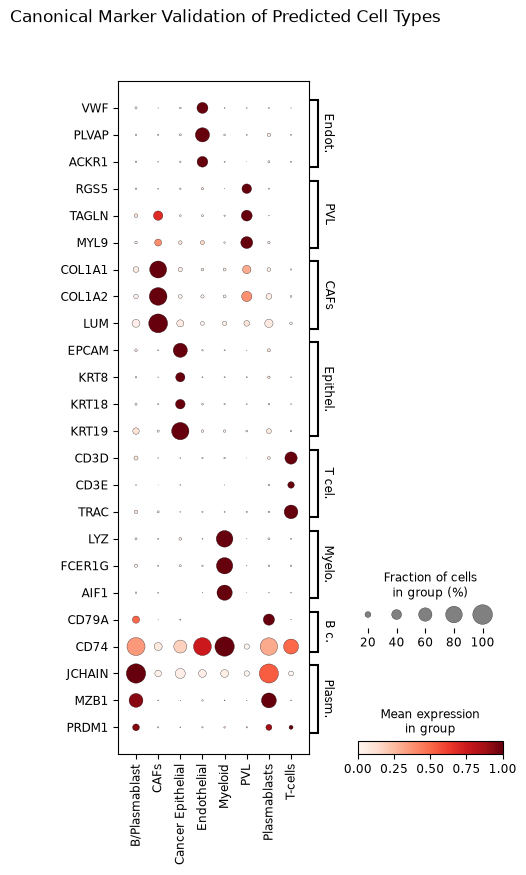

In [10]:
marker_panel = {
    "Endothelial": ["VWF", "PLVAP", "ACKR1"],
    "PVL": ["RGS5", "TAGLN", "MYL9"],
    "CAFs": ["COL1A1", "COL1A2", "LUM"],
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T cells": ["CD3D", "CD3E", "TRAC"],
    "Myeloid": ["LYZ", "FCER1G", "AIF1"],
    "B cells": ["CD79A", "CD74"],
    "Plasmablasts": ["JCHAIN", "MZB1", "PRDM1"]
}

marker_panel_filtered = {
    group: [gene for gene in genes if gene in adata.var_names]
    for group, genes in marker_panel.items()
}

sc.pl.dotplot(
    adata,
    marker_panel_filtered,
    groupby="predicted_celltype",
    standard_scale="var",
    swap_axes=True,
    title="Canonical Marker Validation of Predicted Cell Types"
)

In [11]:
print("=== CELL-TYPE VALIDATION QC ===")

print(f"Cells validated: {adata.n_obs}")
print(f"Predicted cell types: {adata.obs['predicted_celltype'].nunique()}")
print(f"Author major cell types: {adata.obs['celltype_major'].nunique()}")
print(f"Overall annotation agreement: {agreement * 100:.2f}%")

=== CELL-TYPE VALIDATION QC ===
Cells validated: 1534
Predicted cell types: 8
Author major cell types: 9
Overall annotation agreement: 97.65%


## Conclusion

Predicted cell-type annotations derived from unsupervised clustering and marker-gene analysis showed strong agreement with the author-provided cell-type labels (97.65%). Canonical marker expression patterns further supported the biological validity of the inferred cell identities. Minor discrepancies were mainly observed between closely related B-cell/plasmablast states and between malignant and normal epithelial populations.